In [1]:
# Food Recognition and Calorie Estimation

# Import libraries

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras import models

C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hally\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.2 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\hal

In [2]:
# Dataset path

dataset_path = r"Food_subset"

IMG_SIZE = (128, 128)

BATCH_SIZE = 32

In [3]:
# Load Dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Classes:")
print(class_names)

Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.
Classes:
['chicken_curry', 'chicken_wings', 'donuts', 'french_fries', 'fried_rice', 'ice_cream', 'pancakes', 'pizza', 'samosa', 'strawberry_shortcake']


In [4]:
# Normalisation

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [5]:
# Building CNN

model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

C:\Users\hally\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [6]:
# Compile

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# Train

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs= 7
)

Epoch 1/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 130s 493ms/step - accuracy: 0.1620 - loss: 2.2370 - val_accuracy: 0.2830 - val_loss: 2.0242
Epoch 2/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 121s 482ms/step - accuracy: 0.2712 - loss: 2.0102 - val_accuracy: 0.3150 - val_loss: 1.9167
Epoch 3/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 446ms/step - accuracy: 0.3236 - loss: 1.8891 - val_accuracy: 0.3635 - val_loss: 1.8090
Epoch 4/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 415ms/step - accuracy: 0.3970 - loss: 1.7253 - val_accuracy: 0.3675 - val_loss: 1.7965
Epoch 5/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 122s 488ms/step - accuracy: 0.4528 - loss: 1.5647 - val_accuracy: 0.3970 - val_loss: 1.7501
Epoch 6/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 437ms/step - accuracy: 0.5266 - loss: 1.3464 - val_accuracy: 0.4050 - val_loss: 1.7722
Epoch 7/7
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 434ms/step - accuracy: 0.6159 - loss: 1.1187 - val_accuracy: 0.4100 - val_loss: 1.9551


In [8]:
# Evaluate

loss, accuracy = model.evaluate(val_ds)

print("\nAccuracy:", accuracy * 100)

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.4222 - loss: 1.9716

Accuracy: 40.99999964237213


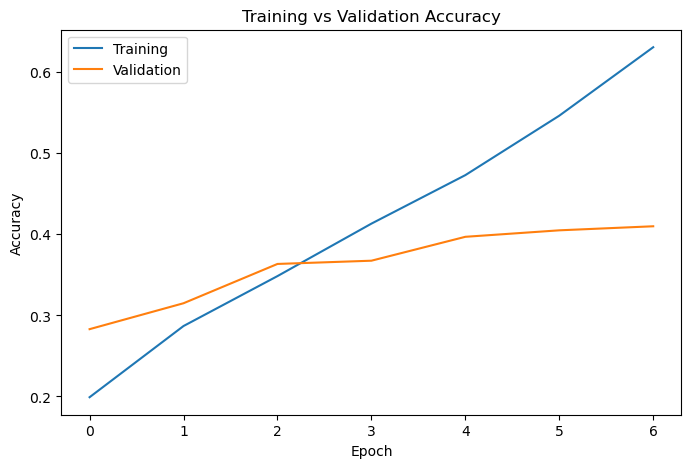

In [9]:
# Accuracy graph

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

In [10]:
# Calorie Map

calorie_map = {
    "pizza": 285,
    "samosa": 262,
    "ice_cream": 207,
    "fried_rice": 330,
    "french_fries": 312,
    "strawberry_shortcake": 250,
    "chicken_wings": 290,
    "donuts": 452,
    "pancakes": 227,
    "chicken_curry": 240
}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step


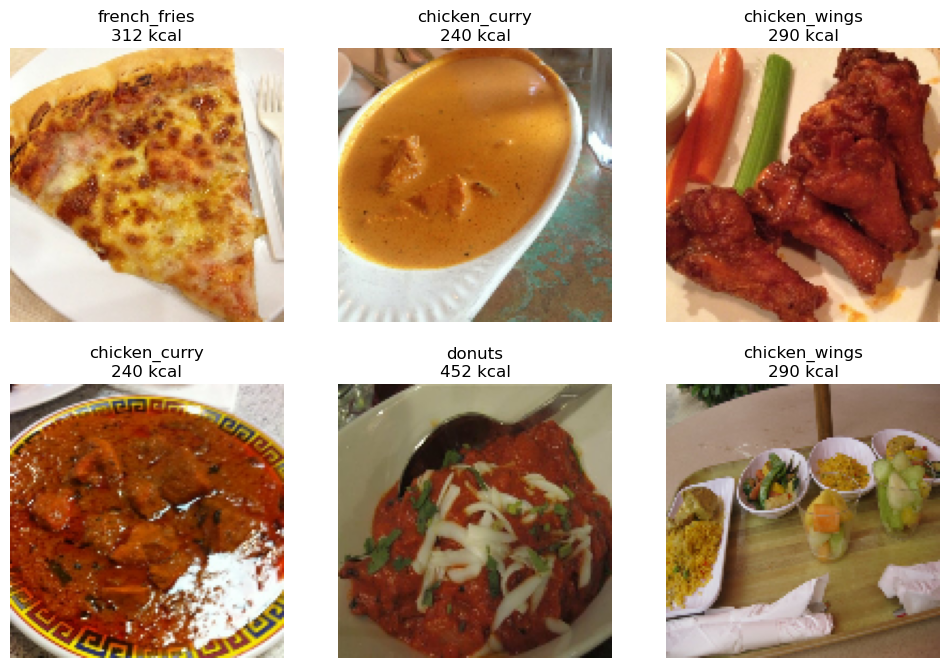

In [11]:
# Predictions

for images, labels in val_ds.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(12,8))

    for i in range(6):

        ax = plt.subplot(2,3,i+1)

        img = images[i].numpy()

        img = (img * 255).astype("uint8")

        plt.imshow(img)

        predicted_class = class_names[
            np.argmax(predictions[i])
        ]

        calories = calorie_map.get(
            predicted_class,
            "Unknown"
        )

        plt.title(
            f"{predicted_class}\n{calories} kcal"
        )

        plt.axis("off")

    plt.show()